In [ ]:
 !pip install gensim

In [ ]:
import math
import string
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
'''
def get_from_file(file_df):
  df=pd.read_csv(file_df)
  df.head()

  # Bilanciamento: prendi lo stesso numero di esempi per ogni classe (undersampling)
  if file_df == "/content/drive/MyDrive/IR_NLP_2025_Shared/Data/MELD DataSet/train_sent_emo.csv":
    min_count = df['Speaker'].value_counts().min()
    df_balanced = df.groupby('Speaker').sample(n=min_count, random_state=42).reset_index(drop=True)
    x=df_balanced['Utterance'].tolist()
    y=df_balanced['Speaker'].tolist()

    return x,y

  x=df['Utterance'].tolist()
  y=df['Speaker'].tolist()
  return x,y
'''
def get_from_file(file_df):
    df = pd.read_csv(file_df)

    # List of selected speakers
    selected_speakers = [
        "Rachel",
        "Monica",
        "Phoebe",
        "Joey",
        "Chandler",
        "Ross"
    ]

    # Filter dataframe
    df_filtered = df[df['Speaker'].isin(selected_speakers)]

    x = df_filtered['Utterance'].tolist()
    y = df_filtered['Speaker'].tolist()

    return x, y

In [ ]:
file_train="/content/drive/MyDrive/IR_NLP_2025_Shared/Data/MELD DataSet/train_sent_emo.csv"

utterance,speaker=get_from_file(file_train)

print(utterance)
print(speaker)

['also I was the point person on my company\x92s transition from the KL-5 to GR-6 system.', 'That I did. That I did.', 'My duties?  All right.', 'I see.', 'Good to know.', 'No don\x92t I beg of you!', 'Really?!', 'But then who? The waitress I went out with last month?', 'You know? Forget it!', 'No-no-no-no, no! Who, who were you talking about?', "No, I-I-I-I don't, I actually don't know", 'Ok!', 'All right, well...', 'Yeah, sure!', 'Hey, Mon.', 'Hey-hey-hey. You wanna hear something that sucks.', 'Do I ever.', 'Chris says they\x92re closing down the bar.', 'No way!', 'Yeah, apparently they\x92re turning it into some kinda coffee place.', 'Just coffee! Where are we gonna hang out now?', 'Got me.', 'Can I get a beer.', 'Hey, did you pick a roommate?', 'You betcha!', 'Is it the Italian guy?', 'Um-mm, yeah right!', 'Oh my God, oh my God! Poor Monica!', 'What, what, what?!', 'What?!', 'He was with her when he wrote this poem.', "Look,  'My vessel so empty with nothing inside.", "Now that I'

In [ ]:
def tokenize(sentences):
  tokenized_list=[]
  for i in sentences:
    i=i.replace('\x92',"'")
    i=i.replace('\x97','-')

    token=nltk.word_tokenize(i)
    token=[word.lower() for word in token]
    tokenized_list.append(token)

  return tokenized_list

In [ ]:
tokenized_utterance=tokenize(utterance)

print(tokenized_utterance)

[['also', 'i', 'was', 'the', 'point', 'person', 'on', 'my', 'company', "'s", 'transition', 'from', 'the', 'kl-5', 'to', 'gr-6', 'system', '.'], ['that', 'i', 'did', '.', 'that', 'i', 'did', '.'], ['my', 'duties', '?', 'all', 'right', '.'], ['i', 'see', '.'], ['good', 'to', 'know', '.'], ['no', 'do', "n't", 'i', 'beg', 'of', 'you', '!'], ['really', '?', '!'], ['but', 'then', 'who', '?', 'the', 'waitress', 'i', 'went', 'out', 'with', 'last', 'month', '?'], ['you', 'know', '?', 'forget', 'it', '!'], ['no-no-no-no', ',', 'no', '!', 'who', ',', 'who', 'were', 'you', 'talking', 'about', '?'], ['no', ',', 'i-i-i-i', 'do', "n't", ',', 'i', 'actually', 'do', "n't", 'know'], ['ok', '!'], ['all', 'right', ',', 'well', '...'], ['yeah', ',', 'sure', '!'], ['hey', ',', 'mon', '.'], ['hey-hey-hey', '.', 'you', 'wan', 'na', 'hear', 'something', 'that', 'sucks', '.'], ['do', 'i', 'ever', '.'], ['chris', 'says', 'they', "'re", 'closing', 'down', 'the', 'bar', '.'], ['no', 'way', '!'], ['yeah', ',', 'app

In [ ]:
from gensim.models import FastText
import numpy as np


# 1. Train FastText (min_count parameter for N-gram)
model = FastText(sentences=tokenized_utterance, vector_size=300, window=5, min_count=3, workers=4)

#print(model.wv['this'])

# Finding words similar to "sentence":
#print(model.wv.most_similar('happy'))

def get_sentence_embedding(tokens, model):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if valid_vectors:
        return np.mean(valid_vectors, axis=0)
    else:
        # null vector for utterances formed by words not in the vocabulary
        return np.zeros(model.vector_size)

# 3. Crea embedding per tutte le frasi
emb_utterance = np.array([get_sentence_embedding(t, model) for t in tokenized_utterance])

In [ ]:
from gensim.models import KeyedVectors
import numpy as np

# Using pretrained model
model = KeyedVectors.load_word2vec_format('/content/drive/MyDrive/IR_NLP_2025_Shared/Angelo Gabriele Cusmano/wiki-news-300d-1M-subword.vec', limit=200000)  # limit per velocizzare, rimuovi in produzione




In [ ]:
def get_sentence_embedding(tokens, model):
    valid_vectors = [model[word] for word in tokens if word in model]
    if valid_vectors:
        return np.mean(valid_vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

emb_utterance = np.array([get_sentence_embedding(t, model) for t in tokenized_utterance])

train set
              precision    recall  f1-score   support

      Rachel       0.31      0.26      0.29      1283
      Monica       0.35      0.40      0.37      1509
      Phoebe       0.33      0.29      0.31      1299
        Joey       0.33      0.26      0.30      1321
    Chandler       0.33      0.39      0.35      1435
        Ross       0.32      0.36      0.34      1459

    accuracy                           0.33      8306
   macro avg       0.33      0.33      0.33      8306
weighted avg       0.33      0.33      0.33      8306



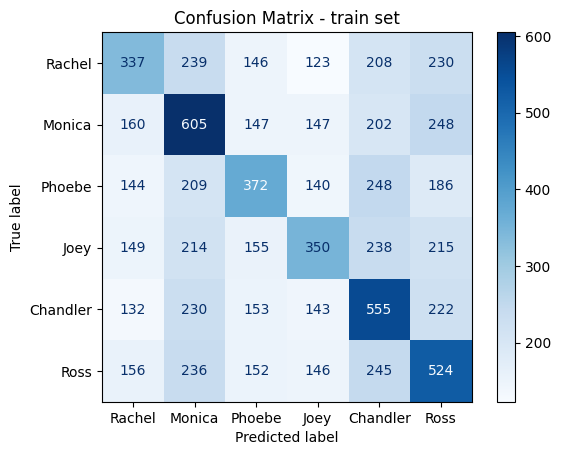

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier

clf = LogisticRegression(
    C=1000,
    max_iter=5000
)

clf.fit(emb_utterance, speaker)

speaker_pred_train = clf.predict(emb_utterance)
print("train set")
print(classification_report(speaker, speaker_pred_train, target_names=["Rachel","Monica","Phoebe","Joey","Chandler","Ross"]))

import matplotlib.pyplot as plt
sentiment_pred_train = clf.predict(emb_utterance)
cm = confusion_matrix(speaker, sentiment_pred_train)

# Visualizzazione confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rachel","Monica","Phoebe","Joey","Chandler","Ross"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - train set")
plt.show()

In [ ]:
file_dev="/content/drive/MyDrive/IR_NLP_2025_Shared/Data/MELD DataSet/dev_sent_emo.csv"

utterance_dev,speaker_dev=get_from_file(file_dev)
tokenized_utterance_dev=tokenize(utterance_dev)

emb_utterance_dev = np.array([get_sentence_embedding(t, model) for t in tokenized_utterance_dev])

dev  set
              precision    recall  f1-score   support

      Rachel       0.13      0.15      0.14       101
      Monica       0.22      0.26      0.24       149
      Phoebe       0.25      0.23      0.24       137
        Joey       0.26      0.21      0.23       185
    Chandler       0.22      0.26      0.23       164
        Ross       0.31      0.27      0.29       217

    accuracy                           0.24       953
   macro avg       0.23      0.23      0.23       953
weighted avg       0.24      0.24      0.24       953



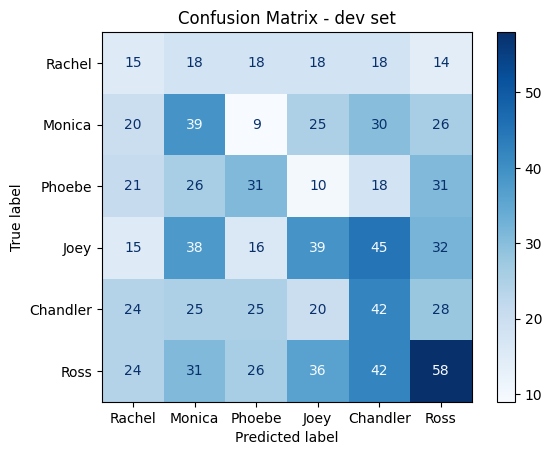

In [ ]:
speaker_pred_dev = clf.predict(emb_utterance_dev)
print("dev  set")
print(classification_report(speaker_dev, speaker_pred_dev, target_names=["Rachel","Monica","Phoebe","Joey","Chandler","Ross"]))

import matplotlib.pyplot as plt
speaker_pred_dev = clf.predict(emb_utterance_dev)
cm = confusion_matrix(speaker_dev, speaker_pred_dev)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rachel","Monica","Phoebe","Joey","Chandler","Ross"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - dev set")
plt.show()

In [ ]:
file_test="/content/drive/MyDrive/test_sent_emo.csv"

utterance_test,speaker_test=get_from_file(file_test)
tokenized_utterance_test=tokenize(utterance_test)

emb_utterance_test = np.array([get_sentence_embedding(t, model) for t in tokenized_utterance_test])

test set
              precision    recall  f1-score   support

      Rachel       0.21      0.16      0.18       379
      Monica       0.26      0.29      0.28       411
      Phoebe       0.18      0.18      0.18       346
        Joey       0.20      0.14      0.16       291
    Chandler       0.21      0.31      0.25       356
        Ross       0.21      0.18      0.19       373

    accuracy                           0.21      2156
   macro avg       0.21      0.21      0.21      2156
weighted avg       0.21      0.21      0.21      2156



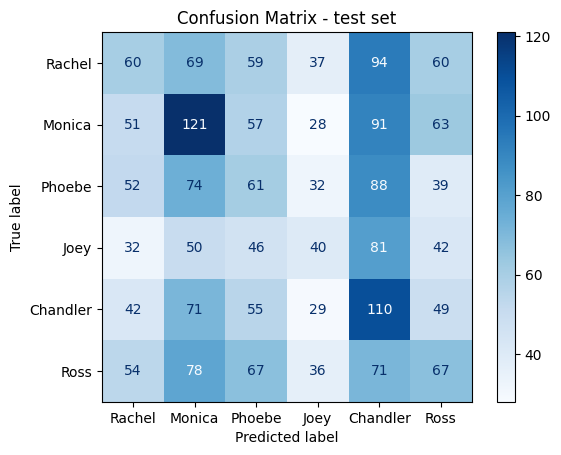

In [ ]:
speaker_pred_test = clf.predict(emb_utterance_test)
print("test set")
print(classification_report(speaker_test, speaker_pred_test, target_names=["Rachel","Monica","Phoebe","Joey","Chandler","Ross"]))

speaker_pred_test = clf.predict(emb_utterance_test)
cm=confusion_matrix(speaker_test, speaker_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rachel","Monica","Phoebe","Joey","Chandler","Ross"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - test set")
plt.show()

In [ ]:
from keras.preprocessing.sequence import pad_sequences

MAX_LEN = 15  # sequence max length

def sentence_to_sequence(sentence, model, max_len=MAX_LEN):
    vectors = [model[word] for word in sentence if word in model]
    if len(vectors) == 0:
        return np.zeros((max_len, model.vector_size))

    sequence = pad_sequences([vectors], maxlen=max_len, dtype='float32', padding='post', truncating='post')[0]
    return sequence

X_train_seq = np.array([sentence_to_sequence(t, model) for t in tokenized_utterance])
X_val_seq = np.array([sentence_to_sequence(t, model) for t in tokenized_utterance_dev])

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(speaker)
y_val = label_encoder.transform(speaker_dev)

num_classes = len(label_encoder.classes_)

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Masking, SimpleRNN

model_rnn = Sequential()

model_rnn.add(Masking(mask_value=0., input_shape=(MAX_LEN, 300)))
model_rnn.add(SimpleRNN(64, return_sequences=True))
#model_rnn.add(SimpleRNN(32, return_sequences=True))
model_rnn.add(SimpleRNN(32))
model_rnn.add(Dropout(0.3))
model_rnn.add(Dense(num_classes, activation='softmax'))

model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_6 (Masking)             │ (None, 15, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 15, 64)         │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,662 (104.15 KB)

 Trainable params: 26,662 (104.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath='best_model.weights.h5',       # nome file dove salvare
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

model_rnn.fit(X_train_seq, y_train, epochs=10, batch_size=64, validation_data=(X_val_seq, y_val), callbacks=[checkpoint])

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1662 - loss: 1.8683
Epoch 1: val_accuracy improved from -inf to 0.20252, saving model to best_model.weights.h5
130/130 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.1662 - loss: 1.8681 - val_accuracy: 0.2025 - val_loss: 1.7932
Epoch 2/10
121/130 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1998 - loss: 1.7959
Epoch 2: val_accuracy improved from 0.20252 to 0.21091, saving model to best_model.weights.h5
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1991 - loss: 1.7963 - val_accuracy: 0.2109 - val_loss: 1.7851
Epoch 3/10
124/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2132 - loss: 1.7727
Epoch 3: val_accuracy did not improve from 0.21091
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2134 - loss: 1.7729 - val_accuracy: 0.2088 - val_loss: 1.8000
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2230 - loss: 1.7612
Epoch 4: val_accuracy did not improve from 0.21091
130/130 ━━━━━━━━

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
              precision    recall  f1-score   support

    Chandler       0.13      0.11      0.12       101
        Joey       0.19      0.17      0.18       149
      Monica       0.18      0.20      0.19       137
      Phoebe       0.27      0.14      0.19       185
      Rachel       0.17      0.26      0.21       164
        Ross       0.30      0.33      0.31       217

    accuracy                           0.21       953
   macro avg       0.21      0.20      0.20       953
weighted avg       0.22      0.21      0.21       953



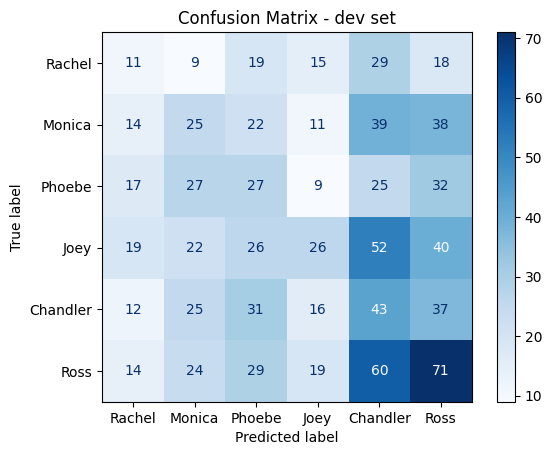

In [ ]:
model_rnn.load_weights('best_model.weights.h5')

from sklearn.metrics import classification_report

y_pred = model_rnn.predict(X_val_seq)

y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_val, y_pred_classes, target_names=label_encoder.classes_))

cm = confusion_matrix(y_val, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rachel","Monica","Phoebe","Joey","Chandler","Ross"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - dev set")
plt.show()


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

    Chandler       0.20      0.13      0.16       379
        Joey       0.22      0.21      0.21       411
      Monica       0.20      0.22      0.21       346
      Phoebe       0.14      0.10      0.12       291
      Rachel       0.20      0.24      0.22       356
        Ross       0.24      0.31      0.27       373

    accuracy                           0.21      2156
   macro avg       0.20      0.20      0.20      2156
weighted avg       0.20      0.21      0.20      2156



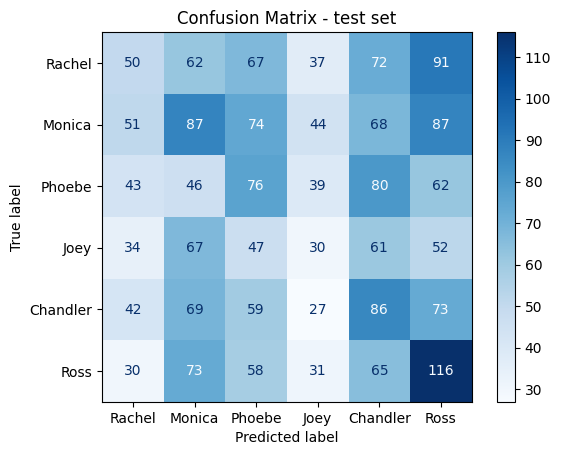

In [ ]:
y_test = label_encoder.transform(speaker_test)
X_test_seq = np.array([sentence_to_sequence(t, model) for t in tokenized_utterance_test])

y_pred = model_rnn.predict(X_test_seq)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rachel","Monica","Phoebe","Joey","Chandler","Ross"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - test set")
plt.show()